--- Optimization Results 800 Evaluations | 50 Population ---
GD:  0.0116
IGD: 0.0145
HV:  0.3174
Pareto Points: 50/800 (6.25%)
Spread (Delta): 0.7859


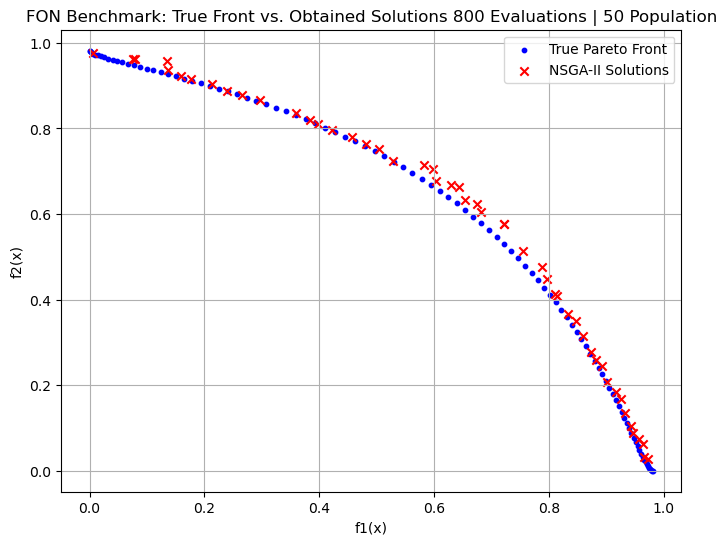

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.indicators.gd import GD
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV

# FON Problem
class FON(Problem):
    def __init__(self):
        super().__init__(n_var=3, n_obj=2, xl=[-4.0]*3, xu=[4.0]*3)

    def _evaluate(self, x, out, *args, **kwargs):
        term1 = np.sum((x - 1/np.sqrt(3))**2, axis=1)
        term2 = np.sum((x + 1/np.sqrt(3))**2, axis=1)
        out["F"] = np.column_stack([1 - np.exp(-term1), 1 - np.exp(-term2)])

# Run NSGA-II (Using 800 evaluations for 16 generations)
num_evals = 800
pop_size = 50
res = minimize(FON(), NSGA2(pop_size=pop_size), ('n_evals', num_evals), seed=42, verbose=False)

# True Pareto Front
x_true = np.linspace(-1/np.sqrt(3), 1/np.sqrt(3), 100)
pf_true = np.column_stack([
    1 - np.exp(-3 * (x_true - 1/np.sqrt(3))**2),
    1 - np.exp(-3 * (x_true + 1/np.sqrt(3))**2)
])

# Quality Indicators and Visualization
if res.F is not None:
    print(f"--- Optimization Results {num_evals} Evaluations | {pop_size} Population ---")
    print(f"GD:  {GD(pf_true)(res.F):.4f}")
    print(f"IGD: {IGD(pf_true)(res.F):.4f}")
    print(f"HV:  {HV(ref_point=np.array([1.0, 1.0]))(res.F):.4f}")
    
    # Pareto Points Calculation
    print(f"Pareto Points: {len(res.F)}/{num_evals} ({(len(res.F) / num_evals) * 100:.2f}%)")

    # Spread (Delta) — guarded against single-point fronts
    F = res.F[np.argsort(res.F[:, 0])]
    if len(F) < 2:
        print("Spread (Delta): N/A (insufficient Pareto points)")
    else:
        d_i = np.linalg.norm(np.diff(F, axis=0), axis=1)
        d_bar = d_i.mean()
        df = np.linalg.norm(pf_true[0]  - F[0])
        dl = np.linalg.norm(pf_true[-1] - F[-1])
        denom = df + dl + (len(F) - 1) * d_bar
        spread = (df + dl + np.sum(np.abs(d_i - d_bar))) / denom if denom > 0 else float('nan')
        print(f"Spread (Delta): {spread:.4f}")

    # Visualization
    plt.figure(figsize=(8, 6))
    plt.scatter(pf_true[:, 0], pf_true[:, 1], label="True Pareto Front", color="blue", s=10)
    plt.scatter(res.F[:, 0], res.F[:, 1], label="NSGA-II Solutions", color="red", marker="x")
    plt.title(f"FON Benchmark: True Front vs. Obtained Solutions {num_evals} Evaluations | {pop_size} Population")
    plt.xlabel("f1(x)")
    plt.ylabel("f2(x)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No feasible solutions found.")